In [ ]:
!pip install openpyx1 xgboost shap

ERROR: Could not find a version that satisfies the requirement openpyx1 (from versions: none)
ERROR: No matching distribution found for openpyx1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("rs.csv")

In [ ]:
df.head()

,Sl.No,STATE,District,Recharge from Rainfall during Monsoon season(Ham),Recharge From Other Sources during monsoon season(Ham),Recharge from Rainfall during non-monsoon season(Ham),Recharge From Other Sources during non-monsoon season(Ham),Annual Replenishable resources(Ham),Annual Natural Discharge (Ham),Net Annual Ground Water Availability (Ham),Draft due to Irrigation Needs(Ham),Draft due to Domestic & Industrial Water Supply Needs(Ham),Total annual Draft(Ham),Projected demand for Domestic and Industrial uses upto 2025 (Ham),Ground Water Availability for Future Irrigation use (Ham),Stage of Ground Water Develop ment (%)
0,1,ANDHRA PRADESH,Srikakulam,40417.0,38297.0,24646.0,19754.0,123115.0,11733.0,111382.0,38291.0,4504.0,42795.0,17584.0,62902.0,38.0
1,2,ANDHRA PRADESH,Vizianagaram,42539.0,22254.0,28250.0,7492.0,100534.0,8936.0,91598.0,16894.0,918.0,17812.0,6116.0,68723.0,19.0
2,3,ANDHRA PRADESH,Visakhapatnam,73586.0,5905.0,13328.0,5271.0,98090.0,8636.0,89454.0,13442.0,4485.0,17927.0,12541.0,63470.0,20.0
3,4,ANDHRA PRADESH,East Godavari,69958.0,37094.0,38290.0,24618.0,169960.0,16007.0,153953.0,33967.0,9075.0,43042.0,14482.0,106654.0,28.0
4,5,ANDHRA PRADESH,West Godavari,58870.0,42876.0,23364.0,45290.0,170399.0,16033.0,154366.0,59783.0,967.0,60750.0,10080.0,85823.0,39.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 662 entries, 0 to 661
Data columns (total 16 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   Sl.No                                                               662 non-null    int64  
 1   STATE                                                               662 non-null    object 
 2   District                                                            662 non-null    object 
 3   Recharge from Rainfall during Monsoon season(Ham)                   651 non-null    float64
 4   Recharge From Other Sources during monsoon season(Ham)              633 non-null    float64
 5   Recharge from Rainfall during non-monsoon season(Ham)               652 non-null    float64
 6   Recharge From Other Sources during non-monsoon season(Ham)          633 non-null    float64
 7   Annual Replenisha

In [ ]:
df.describe()

,Sl.No,Recharge from Rainfall during Monsoon season(Ham),Recharge From Other Sources during monsoon season(Ham),Recharge from Rainfall during non-monsoon season(Ham),Recharge From Other Sources during non-monsoon season(Ham),Annual Replenishable resources(Ham),Annual Natural Discharge (Ham),Net Annual Ground Water Availability (Ham),Draft due to Irrigation Needs(Ham),Draft due to Domestic & Industrial Water Supply Needs(Ham),Total annual Draft(Ham),Projected demand for Domestic and Industrial uses upto 2025 (Ham),Ground Water Availability for Future Irrigation use (Ham),Stage of Ground Water Develop ment (%)
count,662.000000,651.000000,633.000000,652.000000,633.000000,661.000000,660.000000,661.000000,652.000000,661.000000,661.000000,652.000000,651.000000,661.000000
mean,331.500000,39921.859810,11389.723580,6219.474203,11740.867627,67605.056929,5391.082353,62222.133120,35015.219297,3747.013953,38285.469307,4849.539989,24920.340089,61.489589
std,191.247222,34801.442148,17282.387666,9371.231039,13611.389341,56677.140675,5171.067140,52131.162805,43723.156647,3688.796994,45154.838914,4974.559913,38658.101344,50.858506
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-194037.000000,0.000000
25%,166.250000,14554.000000,868.680000,76.192500,1616.390000,26620.679000,2036.550000,23832.000000,3811.467500,1413.580000,5844.680000,1592.000000,4101.010000,27.000000
50%,331.500000,32150.120000,5111.000000,3531.245000,7327.090000,54930.000000,3966.580000,50683.950000,21710.000000,2860.690000,24610.280000,3499.620000,18984.050000,54.000000
75%,496.750000,54485.115000,14245.020000,7410.390000,16751.000000,94394.640000,7022.082500,87889.250000,49973.750000,5019.260000,54693.810000,6545.000000,38198.540000,83.000000
max,662.000000,241691.730000,128976.000000,70126.000000,85132.000000,363854.660000,34991.160000,328863.500000,362759.000000,34160.250000,366426.000000,46578.000000,264315.120000,411.000000


In [ ]:
df.columns = (df.columns.str.strip().str.lower().str.replace(" ","_").str.replace("-","_"))

In [ ]:
print(df.columns)

Index(['sl.no', 'state', 'district',
       'recharge_from_rainfall_during_monsoon_season(ham)',
       'recharge_from_other_sources_during_monsoon_season(ham)',
       'recharge_from_rainfall_during_non_monsoon_season(ham)',
       'recharge_from_other_sources_during_non_monsoon_season(ham)',
       'annual_replenishable_resources(ham)', 'annual_natural_discharge_(ham)',
       'net_annual_ground_water_availability__(ham)',
       'draft_due_to_irrigation_needs(ham)',
       'draft_due_to_domestic_&_industrial_water_supply_needs(ham)',
       'total_annual_draft(ham)',
       'projected_demand_for_domestic_and_industrial_uses__upto_2025_(ham)',
       'ground_water_availability_for_future_irrigation_use_(ham)',
       'stage_of_ground_water_develop_ment_(%)'],
      dtype='object')


In [ ]:
df.dropna(how='all',inplace=True)

In [ ]:
df.isnull().sum()

,0
sl.no,0
state,0
district,0
recharge_from_rainfall_during_monsoon_season(ham),11
recharge_from_other_sources_during_monsoon_season(ham),29
recharge_from_rainfall_during_non_monsoon_season(ham),10
recharge_from_other_sources_during_non_monsoon_season(ham),29
annual_replenishable_resources(ham),1
annual_natural_discharge_(ham),2
net_annual_ground_water_availability__(ham),1


In [ ]:
for col in df.columns:
  if col not in ['state','district']:
    df[col]= pd.to_numeric(df[col],errors = 'coerce')

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
  df[col].fillna(df[col].median(),inplace = True)

/tmp/ipykernel_1001/313879274.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace = True)


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
def classify_risk(stage):
  if stage < 70:
    return "Safe"
  elif stage < 90:
    return "Semi-Critical"
  elif stage < 100:
    return "Critical"
  else:
    return "Over-Exploited"

df["risk_level"] = df["stage_of_ground_water_develop_ment_(%)"].apply(classify_risk)

creating ai features

In [ ]:
df["irrigation_dependency"]=(df['draft_due_to_irrigation_needs(ham)']/df["total_annual_draft(ham)"])

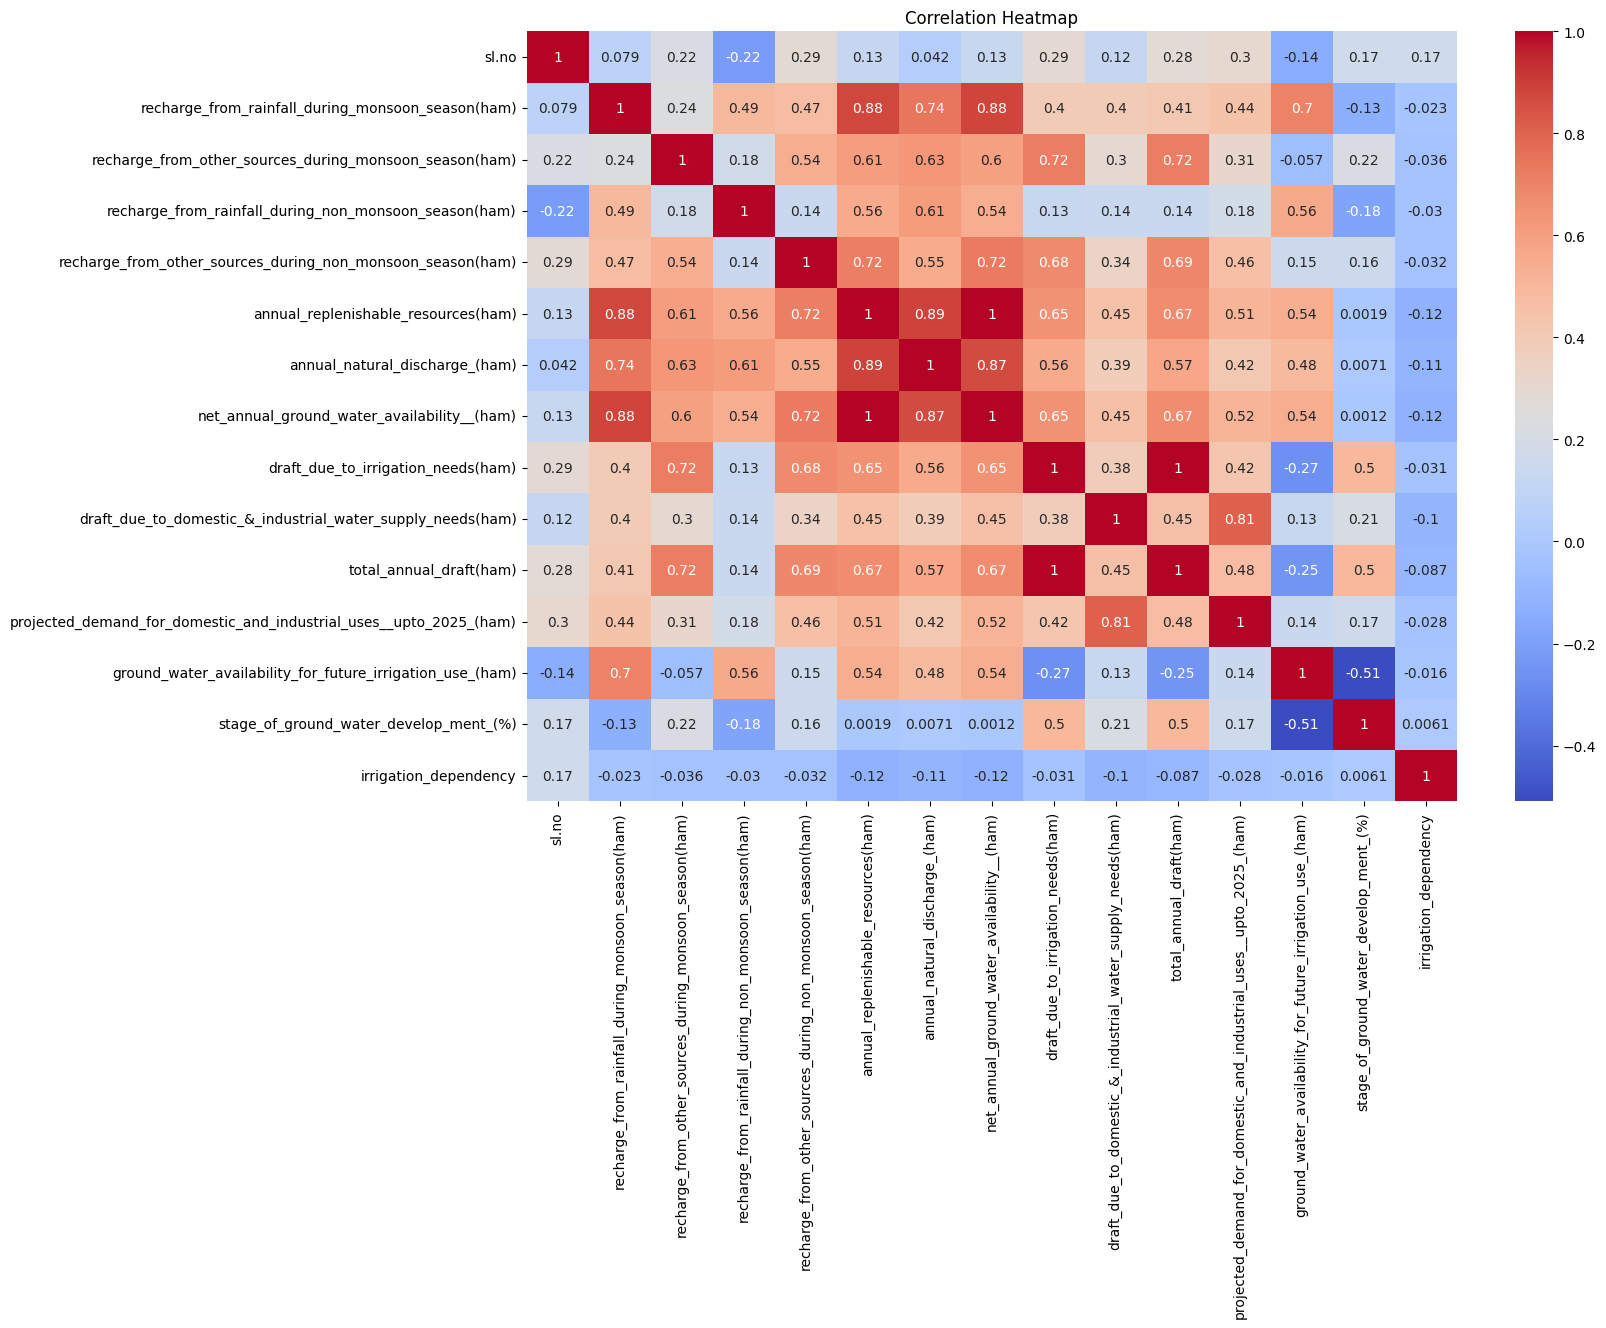

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X = df[['recharge_from_rainfall_during_monsoon_season(ham)',
       'recharge_from_other_sources_during_monsoon_season(ham)',
       'recharge_from_rainfall_during_non_monsoon_season(ham)',
       'recharge_from_other_sources_during_non_monsoon_season(ham)',
       'annual_replenishable_resources(ham)', 'annual_natural_discharge_(ham)',
       'net_annual_ground_water_availability__(ham)',
       'draft_due_to_irrigation_needs(ham)',
       'draft_due_to_domestic_&_industrial_water_supply_needs(ham)',
       'total_annual_draft(ham)',
       'projected_demand_for_domestic_and_industrial_uses__upto_2025_(ham)',
       'ground_water_availability_for_future_irrigation_use_(ham)',
       'stage_of_ground_water_develop_ment_(%)']]

In [ ]:
y = df['risk_level']

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_data = df.select_dtypes(include=np.number)
scaled_data = scaler.fit_transform(numeric_data)
scaled_df = pd.DataFrame(scaled_data,columns=numeric_data.columns)

In [ ]:
X = df.drop(["risk_level"],axis=1)
X = X.select_dtypes(include = np.number)
y= df["risk_level"]

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       1.00      1.00      1.00        22
           2       1.00      1.00      1.00        92
           3       0.93      1.00      0.97        14

    accuracy                           0.99       133
   macro avg       0.98      0.95      0.96       133
weighted avg       0.99      0.99      0.99       133



In [ ]:
importance = model.feature_importances_
feature_importance = pd.DataFrame({'feature':X.columns,'importance':importance})
feature_importance = feature_importance.sort_values(by='importance',ascending=False)
print(feature_importance)

                                              feature  importance
13             stage_of_ground_water_develop_ment_(%)    0.996965
0                                               sl.no    0.001482
11  projected_demand_for_domestic_and_industrial_u...    0.000781
14                              irrigation_dependency    0.000771
3   recharge_from_rainfall_during_non_monsoon_seas...    0.000000
1   recharge_from_rainfall_during_monsoon_season(ham)    0.000000
2   recharge_from_other_sources_during_monsoon_sea...    0.000000
6                      annual_natural_discharge_(ham)    0.000000
5                 annual_replenishable_resources(ham)    0.000000
4   recharge_from_other_sources_during_non_monsoon...    0.000000
7         net_annual_ground_water_availability__(ham)    0.000000
10                            total_annual_draft(ham)    0.000000
9   draft_due_to_domestic_&_industrial_water_suppl...    0.000000
8                  draft_due_to_irrigation_needs(ham)    0.000000
12  ground

In [ ]:
predicted_labels = label_encoder.inverse_transform(y_pred)
actual_labels = label_encoder.inverse_transform(y_test)

In [ ]:
results = pd.DataFrame({'Actual': actual_labels, 'Predicted': predicted_labels})
print(results.head(20))

            Actual       Predicted
0             Safe            Safe
1    Semi-Critical   Semi-Critical
2   Over-Exploited  Over-Exploited
3             Safe            Safe
4         Critical        Critical
5             Safe            Safe
6             Safe            Safe
7    Semi-Critical   Semi-Critical
8             Safe            Safe
9             Safe            Safe
10            Safe            Safe
11  Over-Exploited  Over-Exploited
12            Safe            Safe
13            Safe            Safe
14   Semi-Critical   Semi-Critical
15            Safe            Safe
16            Safe            Safe
17   Semi-Critical   Semi-Critical
18            Safe            Safe
19            Safe            Safe


In [ ]:
from sklearn .metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)*100
print("Accuracy :", accuracy, "%")

Accuracy : 99.24812030075188 %


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       1.00      1.00      1.00        22
           2       1.00      1.00      1.00        92
           3       0.93      1.00      0.97        14

    accuracy                           0.99       133
   macro avg       0.98      0.95      0.96       133
weighted avg       0.99      0.99      0.99       133



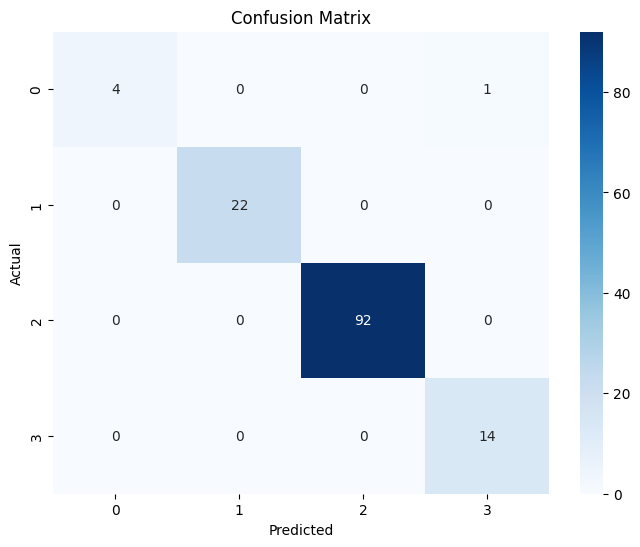

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

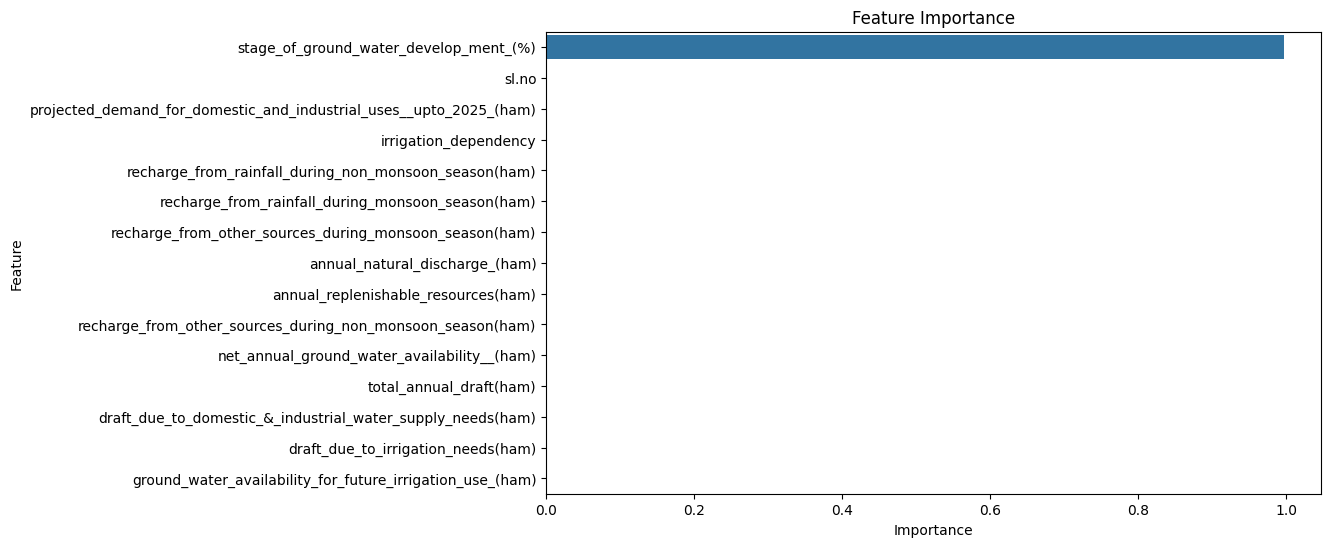

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='importance',y='feature',data=feature_importance)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

In [ ]:
top_features = feature_importance.head(10)
print(top_features)

                                              feature  importance
13             stage_of_ground_water_develop_ment_(%)    0.996965
0                                               sl.no    0.001482
11  projected_demand_for_domestic_and_industrial_u...    0.000781
14                              irrigation_dependency    0.000771
3   recharge_from_rainfall_during_non_monsoon_seas...    0.000000
1   recharge_from_rainfall_during_monsoon_season(ham)    0.000000
2   recharge_from_other_sources_during_monsoon_sea...    0.000000
6                      annual_natural_discharge_(ham)    0.000000
5                 annual_replenishable_resources(ham)    0.000000
4   recharge_from_other_sources_during_non_monsoon...    0.000000


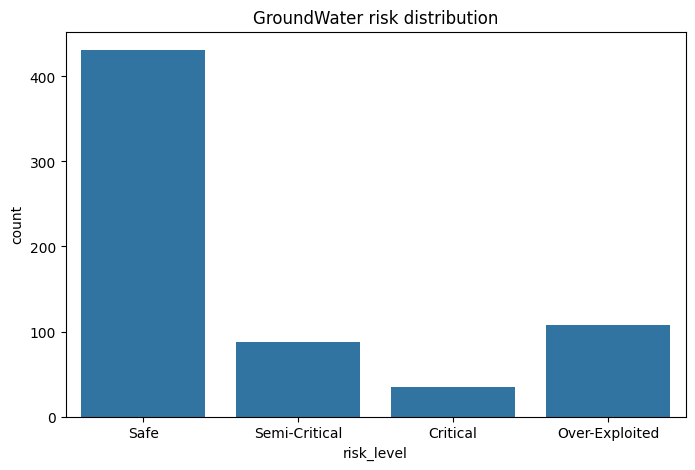

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['risk_level'])
plt.title("GroundWater risk distribution")
plt.show()